## Model Traning and Evaluation

#### New notebook for ML tasks for data science accelerator to keep notebooks small and tidy.

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error

np.random.seed(42)

In [40]:
#define the function to plot the learning curve
def plot_learning_curve(
    estimator,
    title,
    X,
    y,
    axes=None,
    ylim=None,
    cv=None,
    n_jobs=None,
    train_sizes=np.linspace(0.1, 1.0, 5),
):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs fit times curve, the fit times vs score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing `fit` and `predict` methods which
        will be cloned for each validation.

    title : str
        Title for the chart.

    X : array-like of shape (n_samples, n_features)
        Training vector, where ``n_samples`` is the number of samples and
        ``n_features`` is the number of features.

    y : array-like of shape (n_samples) or (n_samples, n_features)
        Target relative to ``X`` for classification or regression;
        None for unsupervised learning.

    axes : array-like of shape (3,), default=None
        Axes to use for plotting the curves.

    ylim : tuple of shape (2,), default=None
        Defines minimum and maximum y-values plotted, e.g. (ymin, ymax).

    cv : int, cross-validation generator or an iterable, default=None
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:

          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, default=None
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like of shape (n_ticks,)
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the ``dtype`` is float, it is regarded
        as a fraction of the maximum size of the training set (that is
        determined by the selected validation method), i.e. it has to be within
        (0, 1]. Otherwise it is interpreted as absolute sizes of the training
        sets. Note that for classification the number of samples usually have
        to be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        return_times=True,
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r",
    )
    axes[0].fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g",
    )
    axes[0].plot(
        train_sizes, train_scores_mean, "o-", color="r", label="Training score"
    )
    axes[0].plot(
        train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation score"
    )
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, "o-")
    axes[1].fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.1,
    )
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_time vs score
    fit_time_argsort = fit_times_mean.argsort()
    fit_time_sorted = fit_times_mean[fit_time_argsort]
    test_scores_mean_sorted = test_scores_mean[fit_time_argsort]
    test_scores_std_sorted = test_scores_std[fit_time_argsort]
    axes[2].grid()
    axes[2].plot(fit_time_sorted, test_scores_mean_sorted, "o-")
    axes[2].fill_between(
        fit_time_sorted,
        test_scores_mean_sorted - test_scores_std_sorted,
        test_scores_mean_sorted + test_scores_std_sorted,
        alpha=0.1,
    )
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt

In [41]:
# read in our processed dataset
df = pd.read_csv('./data/final_df.csv')
print(df.shape)
df.head()

(549900, 11)


,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,gdp_per_cap_o,distw_harmonic,fta_wto,wto_o
0,Aruba,Afghanistan,NaN,14.718799,16.584140,4.621014,10.254067,10.097785,13193.0,0.0,0.0
1,Aruba,Afghanistan,NaN,14.765029,16.698643,4.624306,10.278682,10.140723,13193.0,0.0,0.0
2,Aruba,Afghanistan,NaN,NaN,16.836267,4.628730,10.303087,NaN,13193.0,0.0,0.0
3,Aruba,Afghanistan,NaN,NaN,16.826608,4.633865,10.327175,NaN,13193.0,0.0,0.0
4,Aruba,Afghanistan,NaN,NaN,16.813749,4.642418,10.396903,NaN,13193.0,0.0,0.0


In [42]:
# check size and amount of nulls
print(df.shape)
df.isnull().sum(axis=0)

(549900, 11)


iso3_o                 0
iso3_d                 0
tradeflow_baci    236107
gdp_o              91260
gdp_d              91260
pop_o              62010
pop_d              62010
gdp_per_cap_o      91260
distw_harmonic         0
fta_wto                0
wto_o                  0
dtype: int64

In [43]:
# can we see common trade routes with null traffic
null_countries = df[df['tradeflow_baci'].isnull()]['iso3_o'] + df[df['tradeflow_baci'].isnull()]['iso3_d']
print(f'Number of null routes: {len(null_countries)}')
null_countries.value_counts()

Number of null routes: 236107


ArubaAnguilla                               10
ArubaAlbania                                10
ArubaAndorra                                10
ArubaArmenia                                10
ArubaAmerican Samoa                         10
                                            ..
ZimbabweParaguay                             1
ZimbabweQatar                                1
ZimbabweSeychelles                           1
ZimbabweSaint Vincent and the Grenadines     1
ZimbabweVietnam                              1
Name: count, Length: 32330, dtype: int64

In [44]:
# drop nulls due to sparcity (some countries have too little data to impute/ffill)
df = df.dropna()
df.shape

(271951, 11)

In [45]:
df.head()

,iso3_o,iso3_d,tradeflow_baci,gdp_o,gdp_d,pop_o,pop_d,gdp_per_cap_o,distw_harmonic,fta_wto,wto_o
7,Aruba,Afghanistan,5.076198,14.944387,16.746889,4.657393,10.499466,10.286994,13184.0,0.0,0.0
8,Aruba,Afghanistan,6.931335,14.979359,16.708835,4.661985,10.523309,10.317374,13184.0,0.0,0.0
9,Aruba,Afghanistan,6.087545,15.012476,16.749338,4.666359,10.546440,10.346116,13184.0,0.0,0.0
10,Aruba,Angola,10.824908,14.718799,18.227956,4.621014,9.880686,10.097785,9574.0,0.0,0.0
11,Aruba,Angola,-1.951928,14.765029,18.461015,4.624306,9.912472,10.140723,9574.0,0.0,0.0


# Final Preprocessing Notes

#### <ins>Dropped Nulls</ins>

We have dropped nulls from the final transformed dataset. This was done because for 2 mains reasons:
- Since we have only 10 years of data for our 'final' dataframe there are many instances where we have less than 3rows of data. If we split out our data into train test split prior to back or front filling these, to ensure no leaky data, we may not have enough or any data points to reference in the train/test split. 
- We cannot be certain wich rows are 0's specifically, or missing data. Using fillna with 0 may show incorrect trade relationships between countries.
  
This can have some bias issues for our model. Since we are dropping nulls, and lots of small countries have nulls rows, either by having genuinely no trade between countries, or by virtue that their small and don't release trade figures regularly. This disproportionally filters out smaller countries from the dataframe, so our model will only be accurate for medium to large countries. While this is an issue for holistically wanting to find the trade relationship between countries, business wise we would be more interested in the most efficient use of department resources. So the model is still valuable to model the 'main' or 'most lucrative' trade relationships. 

# Model Training

In [46]:
# split into train test
X = df[['gdp_o', 'gdp_d', 'pop_o', 'pop_d', 'gdp_per_cap_o', 'distw_harmonic', 'fta_wto', 'wto_o']]
y = df['tradeflow_baci']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Can we setup a 'simple' baseline model for each model for benchmark score?
#### We can also fit default models for various algorithms to check starting scores.

In [47]:
# loop through models to get basic cv scores
cv_scores_df = pd.DataFrame()

for model, model_name in zip([LinearRegression(), ElasticNet(), RandomForestRegressor(), GradientBoostingRegressor()],
                 ['linear_regression', 'elastic_net', 'random_forest', 'gradient_boost']):
    start = datetime.datetime.now()
    model_cv_score = cross_val_score(
        model, 
        X_train,
        y_train,
        scoring='neg_root_mean_squared_error',cv=5      
        )
    end = datetime.datetime.now()
    time_taken = end - start

    test_model =  model

    #fit/run gridsearch
    test_model.fit(X_train, y_train)

    # fit predict and measure best model
    
    y_pred = test_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)

    model_cv_score = -model_cv_score
    cv_scores_df = pd.concat([cv_scores_df, pd.DataFrame({
        'model': [model_name]*5,
        'scores': np.exp(model_cv_score),
        'test_score': np.exp(rmse),
        'time_taken': [time_taken.total_seconds()]*5
    }
        )]
    )

In [48]:
cv_scores_df.groupby('model')[['scores', 'test_score', 'time_taken']].mean()

,scores,test_score,time_taken
model,,,
elastic_net,16.795651,16.818870,0.089201
gradient_boost,11.053197,11.046980,67.259771
linear_regression,14.491521,14.569811,0.082120
random_forest,5.781767,5.400510,271.959315


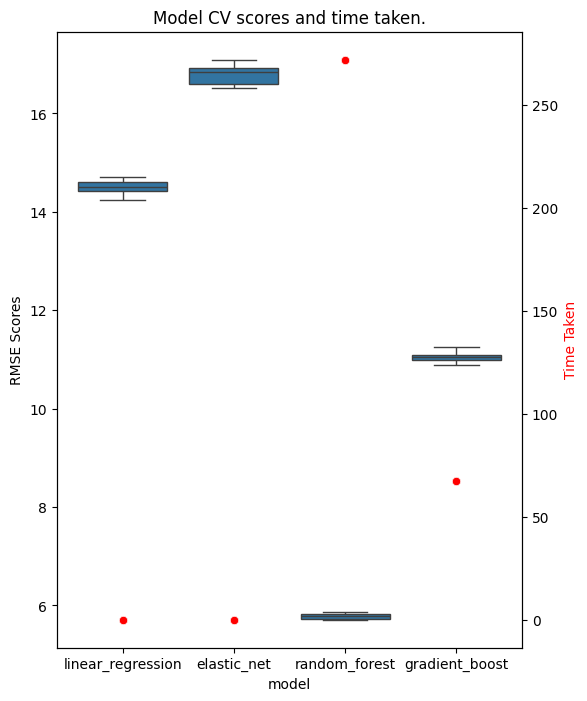

In [49]:
# plot cv scores as a box plot
fig, ax1 = plt.subplots(figsize=(6,8))
sns.boxplot(data=cv_scores_df, x='model', y='scores', ax=ax1)
ax1.set_ylabel('RMSE Scores')

#plot time taken for interest
ax2 = ax1.twinx()
plot = sns.scatterplot(data=cv_scores_df, x='model', y='time_taken', color='red', ax=ax2)
ax2.set_ylabel('Time Taken', color='red')
plt.title('Model CV scores and time taken.')
plt.show()

#### Summary of Baseline Models

Baseline Models:  

|Model|CV RMSE Avg|Test RMSE Avg|Time Taken Seconds|
|---|---|---|---|
|Linear Regression|14.49|14.57|0.23|
|Elastic Net|16.80|16.82|0.20|
|Gradient Boost|11.05|11.47|168.22|
|Random Forest|5.78|5.40|685.45|
  
  
Our summary of baseline models show us that the best model for RMSE accuracy is the random Forest predictor. Gradeint Boost model is also better than the baseline Linear Regression and Elastic Net models even if it isn't as accurate as Random Forest.
  
We can also see that as the accuracy of the models increases so too does the compute time taken to train the model. The linear regression models take less than a second to train. But the Gradient Boost Model takes over 2 mins, with the Random Forest Model takes over 11mins! This has to be taken into account when we diecide which model is the best. Will be training this model once and not again, or saved for further use? If so traning time may not be too much of a factor. But if traning data, parameters change regularly and we want to retrain the models we could start to look at models with 'acceptable' accuracy but faster traning times.
  
For this notebook I will hyper parameter tune all models for pratice, but if I was compute or time limited I would choose a Random Forrest or Linear Regression Model since they train relatively fast, and still have good RMSE scores. Or if i know i only would have to train a model once, accuracy was of the most important ascpet and I could save and use it later I would choose Random Forest. The 'correct' model would depend on the priorities of the business/team.


# Hyper Parameter Tuning

## Linear Regression

In [50]:
# create dataframe for tuned models
tuned_scores_df = pd.DataFrame()

# create a simple LR pipeline
lr_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', LinearRegression())
    ]
)

# simple gridcv params
params = {
    'regressor__positive': [True, False],
    'regressor__n_jobs': [None, 2, 3]
}

# run grid search
lr_grid = GridSearchCV(
    estimator= lr_pipeline, 
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
lr_grid.fit(X_train, y_train)

# fit predict and measure best model
best_lr_model = lr_grid.best_estimator_
y_pred = best_lr_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

tuned_scores_df = pd.concat([tuned_scores_df, pd.DataFrame({
        'model': ['linear_regression']*5,
        'scores': np.exp(rmse)
    })])

print(f'Best Params for LR model: {lr_grid.best_params_}')
print(f'RMSE for LR transformed back: {np.exp(rmse)}')


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params for LR model: {'regressor__n_jobs': None, 'regressor__positive': False}
RMSE for LR transformed back: 14.569811032619082


In [51]:
def check_residuals(y_test, y_pred, title_suffix: str = None): 
    """
    Prints a histogram of a regression model's residuals during training.

    Parameters:
    model: The trained regression model.

    Returns:
    A histogram of the residuals.
    """

    # Get the residuals

    
    residuals = y_test - y_pred

    # Histogram of the Residuals
    plt.hist(residuals, bins=30, edgecolor='k')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Residuals (Log){' ' + title_suffix if title_suffix else ''}')
    return plt.show()

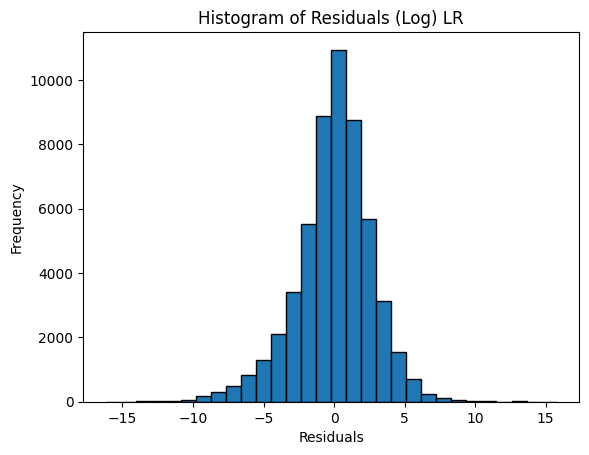

In [52]:
check_residuals(y_test, y_pred, 'LR')

#### Linear Regression Model gives very good accuracy for a simple model. We can start to look at other models to find out if they can improve upon LR's scores

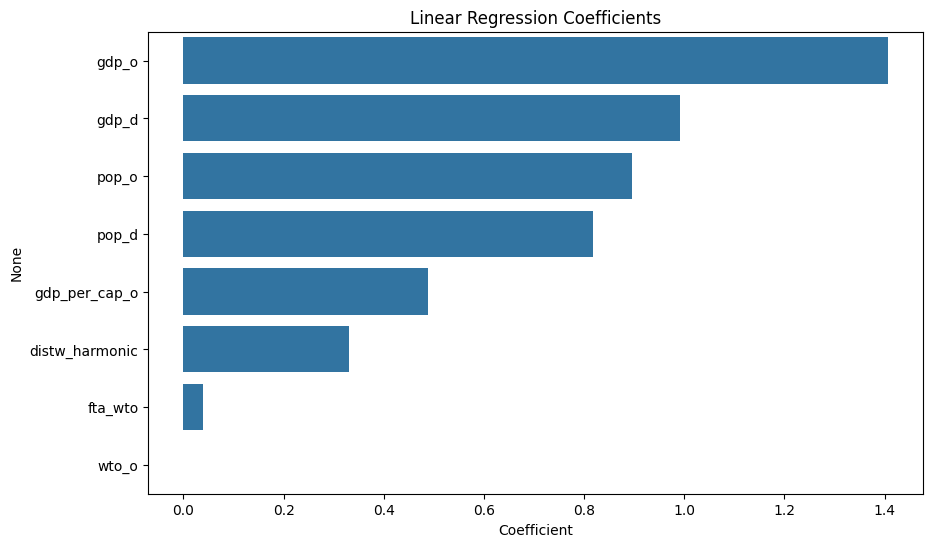

In [53]:
# can we find coefficients for the LR model?
lr_model = LinearRegression(**{'n_jobs': None, 'positive': False})
lr_model.fit(X_train, y_train)

#make df of coeff's
lr_coef = pd.DataFrame(lr_model.coef_, index=X.columns, columns=['Coefficient'])
lr_coef.sort_values(by='Coefficient', ascending=False)

# plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y=lr_coef.index, data=lr_coef.sort_values(by='Coefficient', ascending=False))
plt.title('Linear Regression Coefficients')
plt.show();

<module 'matplotlib.pyplot' from '/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

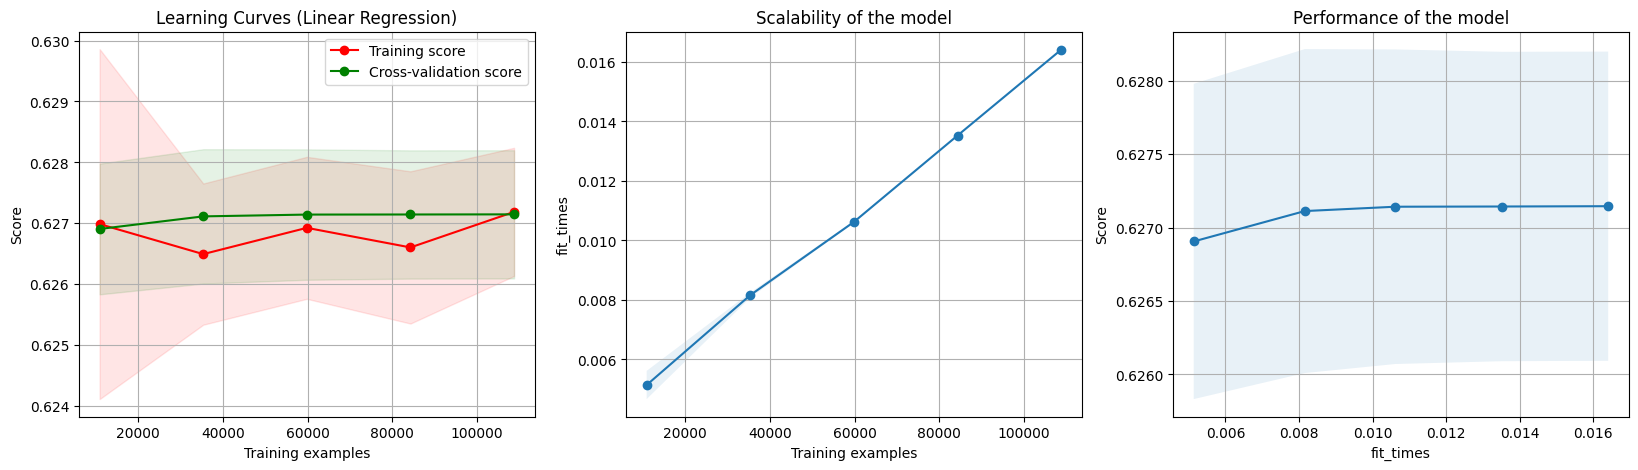

In [54]:
# plot learning curves of lr
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(best_lr_model, 'Learning Curves (Linear Regression)', X_train, y_train, axes=axes, cv=2, n_jobs=1)

## ElasticNet Regressor

In [55]:
# create a simple LR pipeline
en_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', ElasticNet())
    ]
)

# simple gridcv params
params = {
    'regressor__warm_start': [False, True],
    'regressor__l1_ratio': [0, 0.5, 1]
}

# run grid search
en_grid = GridSearchCV(
    estimator= en_pipeline, 
    param_grid=params,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
en_grid.fit(X_train, y_train)

# fit predict and measure best model
best_en_model = en_grid.best_estimator_
y_pred = best_en_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

tuned_scores_df = pd.concat([tuned_scores_df, pd.DataFrame({
        'model': ['elastic_net']*5,
        'scores': np.exp(rmse)
    })])

print(f'Best Params for Enet model: {en_grid.best_params_}')
print(f'RMSE for Enet transformed back: {np.exp(rmse)}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.040e+06, tolerance: 3.335e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.042e+06, tolerance: 3.348e+02
Linear regression models with a zero l1 penalization strength are more effici

Best Params for Enet model: {'regressor__l1_ratio': 0, 'regressor__warm_start': False}
RMSE for Enet transformed back: 20.731726240757748


/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.300e+06, tolerance: 4.171e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.501e+04, tolerance: 2.095e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.128e+05, tolerance: 6.818e+01
Linear regression models with a zero l1 penalization strength are more effici

<module 'matplotlib.pyplot' from '/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

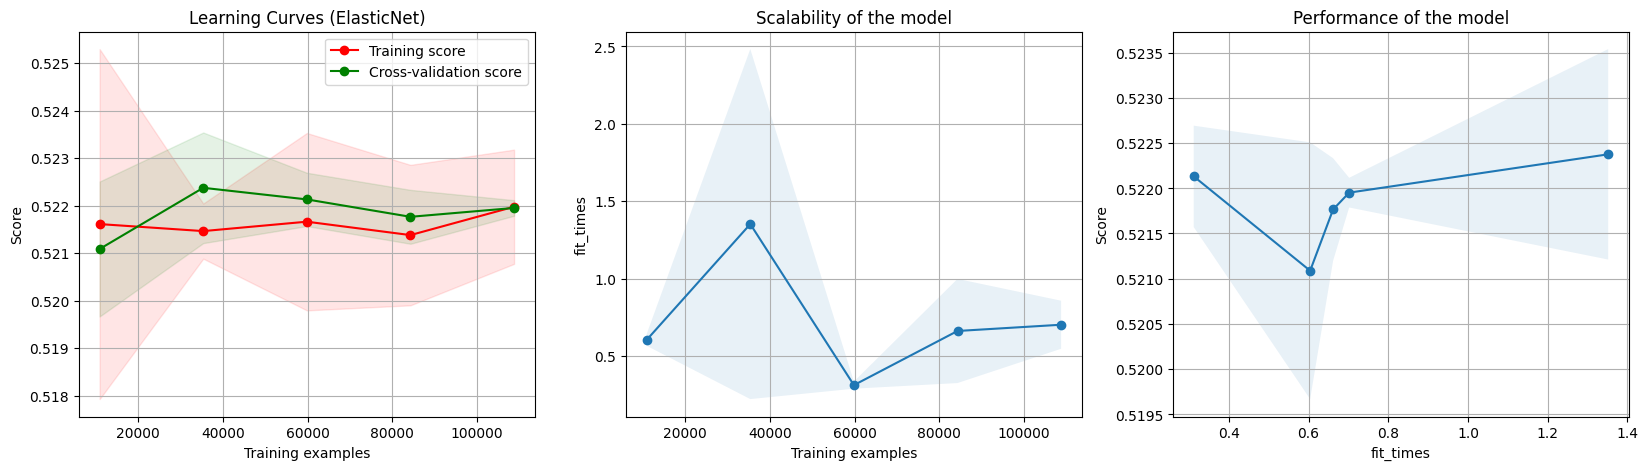

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(best_en_model, 'Learning Curves (ElasticNet)', X_train, y_train, axes=axes, cv=2, n_jobs=1)

## Random Forrest Regressor


In [57]:
# create a simple LR pipeline
rf_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor())
    ]
)

# simple gridcv params
params = {
    'regressor__max_depth': [None, 5, 10],
    'regressor__min_samples_split': [1, 3],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_leaf_nodes': [None, 3, 5]
}

# run grid search
rf_grid = GridSearchCV(
    estimator= rf_pipeline, 
    param_grid=params,
    n_jobs=2, 
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
rf_grid.fit(X_train, y_train)

# fit predict and measure best model
best_rf_model = rf_grid.best_estimator_
y_pred = best_rf_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

tuned_scores_df = pd.concat([tuned_scores_df, pd.DataFrame({
        'model': ['random_forest']*5,
        'scores': np.exp(rmse)
    })])

print(f'Best Params for RF model: {rf_grid.best_params_}')
print(f'RMSE for RF transformed back: {np.exp(rmse)}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
90 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *ar

Best Params for RF model: {'regressor__max_depth': None, 'regressor__max_leaf_nodes': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 3}
RMSE for RF transformed back: 5.399612810366343


<module 'matplotlib.pyplot' from '/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

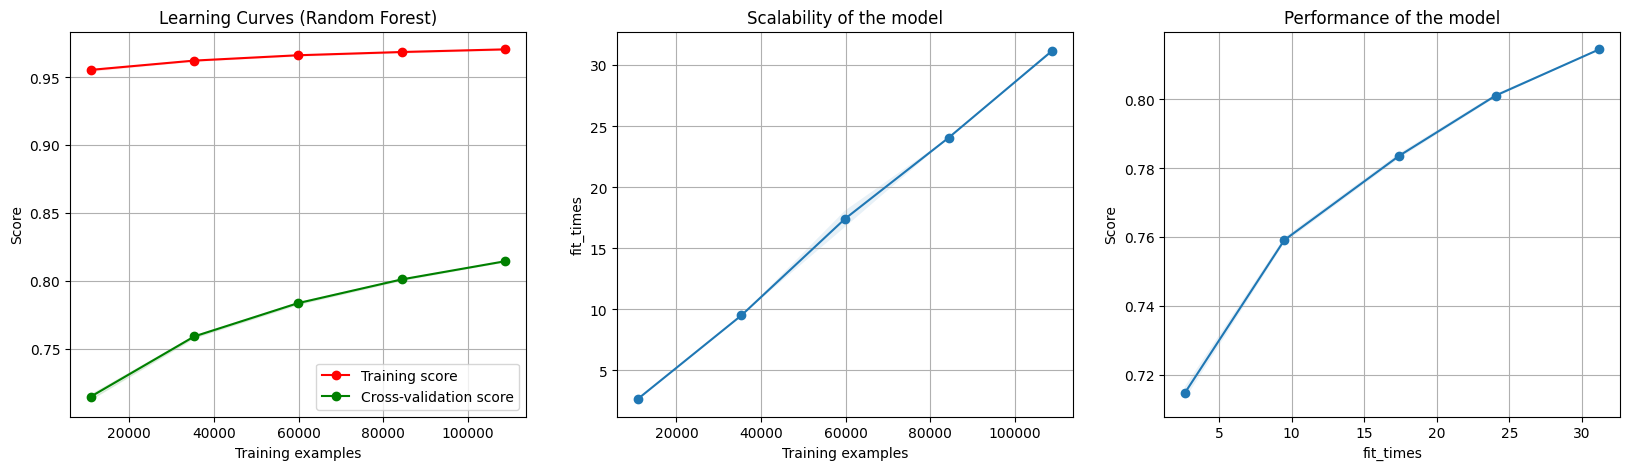

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(best_rf_model, 'Learning Curves (Random Forest)', X_train, y_train, axes=axes, cv=2, n_jobs=1)

## Gradient Boost Regressor

In [59]:
# create a simple LR pipeline
gb_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('regressor', GradientBoostingRegressor())
    ]
)

# simple gridcv params
params = {
    'regressor__n_estimators': [20, 50, 100],
    'regressor__min_samples_split': [2, 3],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__max_leaf_nodes': [None, 3, 5]
}

# run grid search
gb_grid = GridSearchCV(
    estimator= gb_pipeline, 
    param_grid=params,
    n_jobs=2, 
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1
)

#fit/run gridsearch
gb_grid.fit(X_train, y_train)

# fit predict and measure best model
best_gb_model = gb_grid.best_estimator_
y_pred = best_gb_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

tuned_scores_df = pd.concat([tuned_scores_df, pd.DataFrame({
        'model': ['gradient_boost']*5,
        'scores': np.exp(rmse)
    })])

print(f'Best Params for GB model: {gb_grid.best_params_}')
print(f'RMSE for GB transformed back: {np.exp(rmse)}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params for GB model: {'regressor__max_leaf_nodes': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}
RMSE for GB transformed back: 11.04697997408299


<module 'matplotlib.pyplot' from '/home/dan-coles/Documents/code/python/dc_accelerator/venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

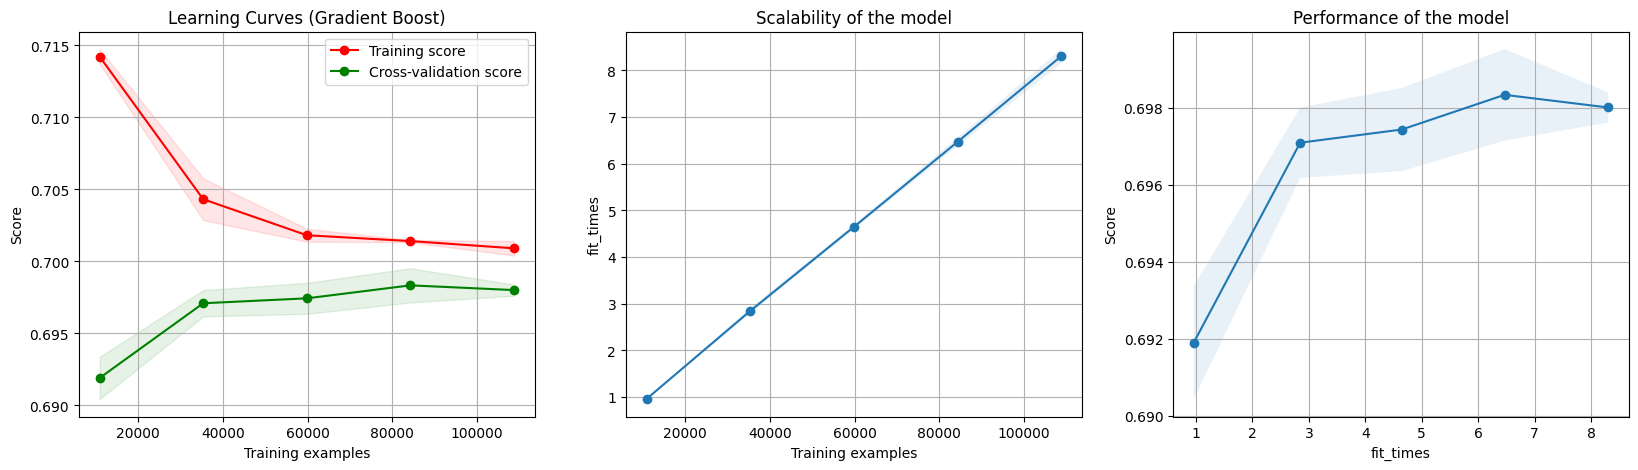

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(best_gb_model, 'Learning Curves (Gradient Boost)', X_train, y_train, axes=axes, cv=2, n_jobs=1)

Can we get a plot a box diagram of the new tuned 'best model' scores and see how they compare to the old scores?

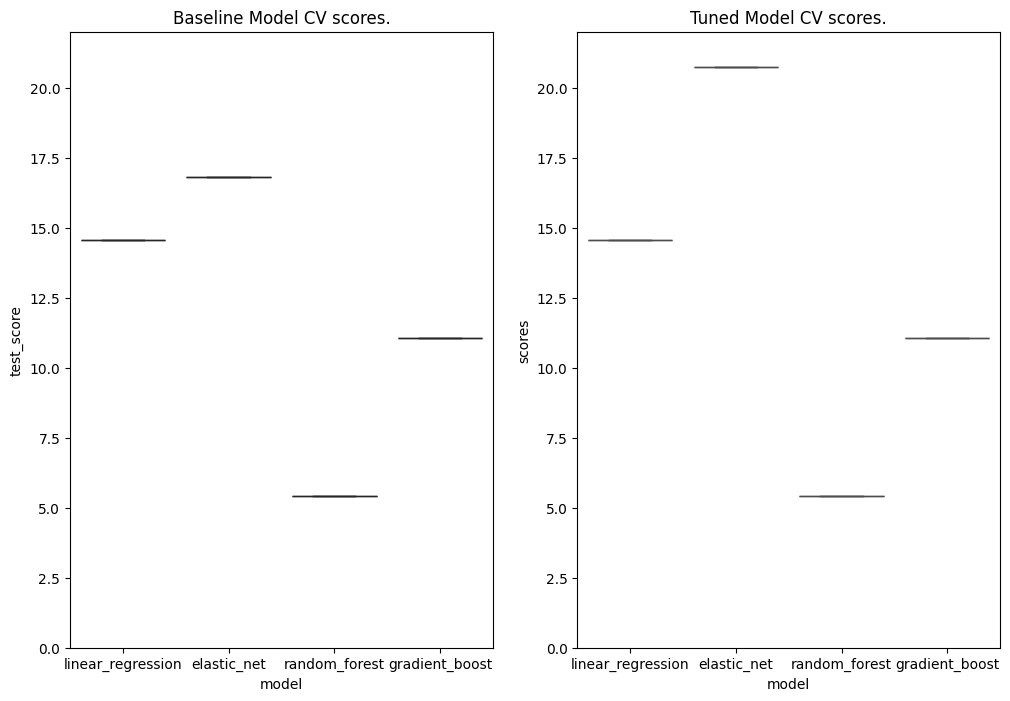

In [61]:
# plot cv scores as a box plot
fig, ax1 = plt.subplots(1, 2, figsize=(12,8))
sns.boxplot(data=cv_scores_df, x='model', y='test_score', ax=ax1[0], color= 'green')
ax1[0].set_title('Baseline Model CV scores.')
ax1[0].set_ylim(0,22)

#plot tuned models for comparison
sns.boxplot(data=tuned_scores_df, x='model', y='scores', color='red', ax=ax1[1])
ax1[1].set_title('Tuned Model CV scores.')
ax1[1].set_ylim(0,22)
plt.show()

We can see that even though it takes a long time to hypertune the models, there is only a small amount of improvement in the RMSE scored for each of the models.

## LR Summary

After conducting hyperparameter tuning for linear regression we can see that the best model has params of n_jobs = None, positive = False. And this gives us a test RMSE score (after exp transformed back) of 14.57. This is exactly the same as the baseline model. So hyperparameter tuning didn't help to increase accuracy, but it also ran very fast so wasn't too much of wasted resource.
  
Our residuals also are normally distributed which shows us that the linear regression model manages to find a suitable best fit line which fits well to the datapoints.
  
We can also see from the plot that the assigned coefficients are much higher for gpd, pop, first of origin then of destination. Then gdp per cap, distance and free trade agreement and world trade agreement having a very low or no coefficient. Thus we can say that the gdp and pop are much higher predictors of potential tradeflow. This also mirrors our NULL dropping strategy. We could investigate this by filling in NULLS with 0s and see how it changes the models.
  
We can also see from the learning curve plots thats more data isn't likely to help increase RMSE scores, but it does increase fit times albeit its still very fast.

## ElasticNet Summary

Hyperparameter tuning for the ElasticNet Model shows us something very interesting. Our accuracy actually get worse from 16.82 to 20.73. The model traning also raises warning stating that because of a zero L1 penalty we should instead use RidgeRegression Model instead. 
  
Our learning curce also shows us that more data won't help to increase accuracy, but it does result in a outsided increase in learning time. 
  
Because of this this model is outright not suitable for our problem.

## Random forest Regressor Summary

Hyper parameter tuning also didn't help the Random Forest Model either. Both produced the same 5.4 RMSE. The best params also were very similar to the default the model starts with. As an improvement to this i could have a much larger grid to search to find if there is a better set of params which would make a better model. One drawback of this though is that this model already has the longest traning time. 
  
Our learning curve show us that as we feed the model more data it also increases accuracy. This suggests that we could feed the model more years worth of data in order to further train the model. This may also have an effect of tuning as it may change what it decides is the best params. It also needs more data so that it doesn't overfit based on traning data. This is shown by the high training score, but lower test scores.



## Gradient Boost Summary
  
Hyperparameter tuning doesn't make a difference to this model either. The RMSE remains at 11.47 and gives params of max_leaf_nods = None, min_samples_leaf = 2, min_smaples_split =3 and n_estimators =100. These similarly to RF are very close to the default parameters. It would be that a larger more exhaustive search could provide more options which could result in a parameter combination which lowers RMSE more. 
  
Our learning curve plot shows us that adding more data to the model doesn't increase accuracy anymore than what we have already have, and traning time icreases.



## Conclusion

We have found that we can fairly accurately predict trade flow between nations based mainly off GDP and POP of the two pairs of nations. There are other factors which come into play, but the aforementioned factors, first of the origin, then the diestivation country are the most important factors. 
  
We can also see that different models do make a difference to the model. A simple linear regression is very fast and fairly accurate, but a random forest model is extremely accrate, albeit takes a very long time to fit the model. 

## Limitations and Further Research

One large limiation of this project is the dropping on NULL rows. These are proportionally small countries. Because of this we must make a note that this model is oly suitable for medium to large countries. Or countries which already have measured trade and thus we can predict a change in already trading countries. Further work could check if we replace all tradeflow NULLs with 0 and see if that helps to increase model performance.

Another limitation is the hyper param tuning of the models. We only use 4 years, drop lots of rows and we still find that the models take a very long time to tune. If we had more computer or more time we could play with more params to check if other combinations make better predictions.